In [1]:
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
torch.set_num_threads(1)
device = torch.device("cpu")
torch.manual_seed(0)
np.random.seed(1)

In [3]:

w1, w2, w3 = 0.2, 0.2, 0.6
mu1 = torch.tensor([-5.0, -5.0], device=device)
mu2 = torch.tensor([ 5.0,  5.0], device=device)
mu3 = torch.tensor([-5.0,  5.0], device=device)
sigma2 = 1.5  

def sample_mog(n: int) -> torch.Tensor:
    z = torch.rand(n, device=device)
    c1 = (z < w1).float().unsqueeze(1)
    c2 = ((z >= w1) & (z < w1 + w2)).float().unsqueeze(1)
    c3 = 1.0 - c1 - c2
    mu = c1 * mu1 + c2 * mu2 + c3 * mu3
    return mu + torch.randn(n, 2, device=device) * math.sqrt(sigma2)

In [4]:
def log_normal_unnorm(x: torch.Tensor, mu: torch.Tensor) -> torch.Tensor:
    return -((x - mu) ** 2).sum(dim=1) / (2 * sigma2)

@torch.no_grad()
def true_score_mog(x: torch.Tensor) -> torch.Tensor:
    a1 = math.log(w1) + log_normal_unnorm(x, mu1)
    a2 = math.log(w2) + log_normal_unnorm(x, mu2)
    a3 = math.log(w3) + log_normal_unnorm(x, mu3)

    A = torch.stack([a1, a2, a3], dim=1)     
    R = torch.softmax(A, dim=1)              
    r1, r2, r3 = R[:,0:1], R[:,1:2], R[:,2:3]

    s1 = (mu1 - x) / sigma2
    s2 = (mu2 - x) / sigma2
    s3 = (mu3 - x) / sigma2
    return r1 * s1 + r2 * s2 + r3 * s3

In [5]:
class ScoreNet(nn.Module):
    def __init__(self, d=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, d),
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
def ssm_loss(model, x):
    x.requires_grad_(True)
    v = torch.randint_like(x, 0, 2).float() * 2 - 1.0
    s = model(x)
    v_dot_s = torch.sum(v * s, dim=-1)
    grad_v_dot_s = torch.autograd.grad(
        outputs=v_dot_s.sum(), inputs=x, create_graph=True
    )[0]
    v_dot_grad_v = torch.sum(v * grad_v_dot_s, dim=-1)
    return (0.5 * torch.sum(s ** 2, dim=-1) + v_dot_grad_v).mean()

def dsm_loss(model: nn.Module, x: torch.Tensor, sigma: float) -> torch.Tensor:
    eps = torch.randn_like(x)
    x_tilde = x + sigma * eps
    target = -(x_tilde - x) / (sigma ** 2)  
    pred = model(x_tilde)
    return 0.5 * (pred - target).pow(2).sum(dim=1).mean() *(sigma**2)


def fdsm_loss(model, x, epsilon=0.01):
    v = torch.randint_like(x, 0, 2).float() * 2 - 1.0  
    v_scaled = v * epsilon
    
    # parallelise 
    x_plus = x + v_scaled
    x_minus = x - v_scaled
    x_combined = torch.cat([x_plus, x_minus], dim=0)

    s_combined = model(x_combined)
    s_plus, s_minus = torch.chunk(s_combined, 2, dim=0)
    
    term1 = 0.125 * torch.sum((s_plus + s_minus) ** 2, dim=-1)
    
    v_dot_s_plus = torch.sum(v_scaled * s_plus, dim=-1)
    v_dot_s_minus = torch.sum(v_scaled * s_minus, dim=-1)
    term2 = (1.0 / (2 * epsilon ** 2)) * (v_dot_s_plus - v_dot_s_minus)
    
    loss = term1 + term2
    return loss.mean()

In [7]:
def train_model(loss_fn, steps=3000, batch_size=128, lr=2e-3, seed=0, tag=""):
    torch.manual_seed(seed)
    model = ScoreNet().to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    losses = []
    t0 = time.perf_counter()

    for t in range(steps):
        x = sample_mog(batch_size)
        opt.zero_grad(set_to_none=True)
        loss = loss_fn(model, x)
        loss.backward()
        opt.step()

        losses.append(float(loss.detach().cpu()))
        if t % 500 == 0:
            print(f"[{tag}] step {t:4d} | loss {losses[-1]:.4f}")

    t1 = time.perf_counter()
    total_s = t1 - t0
    step_ms = 1000.0 * total_s / steps
    print(f"[{tag}] total time: {total_s:.2f}s | per step: {step_ms:.2f} ms\n")

    return model, np.array(losses)

def train_ssm(steps=3000, batch_size=128, lr=2e-3, seed=0):
    return train_model(lambda m, x: ssm_loss(m, x), steps, batch_size, lr, seed, tag="SSM")


def train_dsm(steps=3000, batch_size=128, lr=2e-3, seed=0, sigma=2.0):
    return train_model(lambda m, x: dsm_loss(m, x, sigma=sigma), steps, batch_size, lr, seed, tag=f"DSM σ={sigma}")

def train_fdsm(steps=3000, batch_size=128, lr=2e-3, seed=0):
    return train_model(lambda m, x: fdsm_loss(m, x), steps, batch_size, lr, seed, tag=f"FDSM")

In [ ]:
steps = 2000
batch_size = 64
lr = 1e-3
seed = 0

dsm_sigma = 0.4
dsm_sigma2 = 1

ssm_model, ssm_losses = train_ssm(steps=steps, batch_size=batch_size, lr=lr, seed=seed)
fdsm_model, fdsm_losses = train_fdsm(steps=steps, batch_size=batch_size, lr=lr, seed=seed)
dsm05_model, dsm_losses05 = train_dsm(steps=steps, batch_size=batch_size, lr=lr, seed=seed, sigma=dsm_sigma)
dsm1_model, dsm_losses1 = train_dsm(steps=steps, batch_size=batch_size, lr=lr, seed=seed, sigma=dsm_sigma2)

[SSM] step    0 | loss 0.0072
[SSM] step  500 | loss -0.6080
[SSM] step 1000 | loss -0.7131
[SSM] step 1500 | loss -0.6106
[SSM] total time: 3.43s | per step: 1.72 ms

[FDSM] step    0 | loss 0.0072
[FDSM] step  500 | loss -0.6081
[FDSM] step 1000 | loss -0.7131
[FDSM] step 1500 | loss -0.6106
[FDSM] total time: 2.72s | per step: 1.36 ms

[DSM σ=0.4] step    0 | loss 1.1586
[DSM σ=0.4] step  500 | loss 0.9959
[DSM σ=0.4] step 1000 | loss 0.8673
[DSM σ=0.4] step 1500 | loss 0.8783
[DSM σ=0.4] total time: 1.98s | per step: 0.99 ms

[DSM σ=1] step    0 | loss 1.1641
[DSM σ=1] step  500 | loss 0.6908
[DSM σ=1] step 1000 | loss 0.5618
[DSM σ=1] step 1500 | loss 0.6183
[DSM σ=1] total time: 2.02s | per step: 1.01 ms



In [ ]:
def make_panel(score_fn, title, lim=10.0, n_grid=27, arrow_scale=0.35,
               samples_for_density=None, rects=None, low_rect=None, device="cpu"):
    
    xs = torch.linspace(-lim, lim, n_grid)
    ys = torch.linspace(-lim, lim, n_grid)
    gx, gy = torch.meshgrid(xs, ys, indexing="xy")
    grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1).to(device)

    with torch.no_grad():
        S = score_fn(grid).cpu().numpy()
    
    grid_np = grid.cpu().numpy()

    fig, ax = plt.subplots(figsize=(6.5, 6.5))

    #density Heatmap
    if samples_for_density is not None:
        ax.hist2d(samples_for_density[:, 0], samples_for_density[:, 1], 
                  bins=120, range=[[-lim, lim], [-lim, lim]], 
                  cmap="Blues", alpha=0.9)

    #vectors
    ax.quiver(grid_np[:, 0], grid_np[:, 1], S[:, 0], S[:, 1],
              angles='xy', scale_units='xy', scale=1/arrow_scale, 
              color="black", width=0.003)

    def draw_rect(r, color, lw):
        ax.add_patch(patches.Rectangle((r[0], r[2]), r[1]-r[0], r[3]-r[2],
                                       edgecolor=color, facecolor='none', 
                                       linewidth=lw, linestyle='--'))
    if rects:
        for r in rects: draw_rect(r, "red", 2)
    if low_rect:
        draw_rect(low_rect, "green", 3)

    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), title=title, aspect='equal')
    plt.tight_layout()
    
    return fig

In [11]:
def mode_box(mu, half_width=2.0):
    return (
        mu[0].item() - half_width, mu[0].item() + half_width,
        mu[1].item() - half_width, mu[1].item() + half_width
    )

R1 = mode_box(mu1, half_width=2.0)
R2 = mode_box(mu2, half_width=2.0)
R3 = mode_box(mu3, half_width=2.0)
Rm = (2.0,0.0,-6.0,-4.0)  # middle (low density)
samples = sample_mog(200000).cpu().numpy()
rectangles = [
    R1,
    R2,
    R3,
]


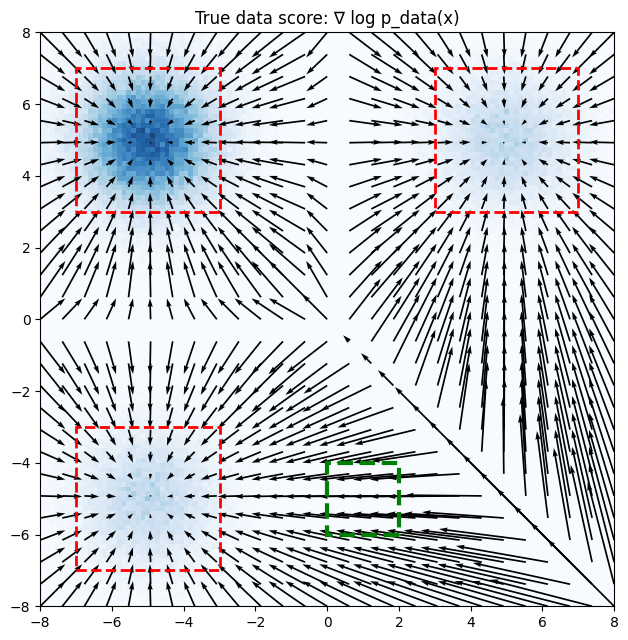

In [12]:
fig_true = make_panel(
    score_fn=lambda x: true_score_mog(x),
    title="True data score: ∇ log p_data(x)",
    lim=8.0, n_grid=27, arrow_scale=0.35,
    samples_for_density=samples,
    rects=rectangles,
    low_rect = Rm
)
plt.show()


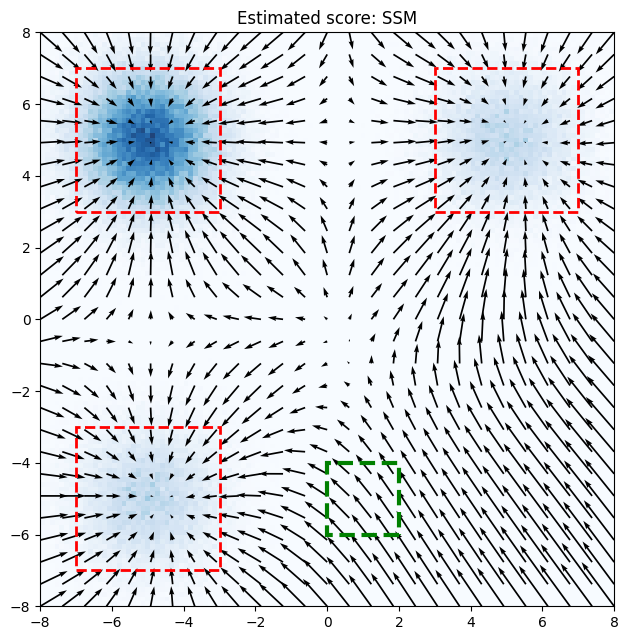

In [13]:
fig_ssm = make_panel(
    score_fn=lambda x: ssm_model(x),
    title="Estimated score: SSM",
    lim=8.0, n_grid=27, arrow_scale=0.35,
    samples_for_density=samples,
    rects=rectangles,
    low_rect = Rm
)
plt.show()

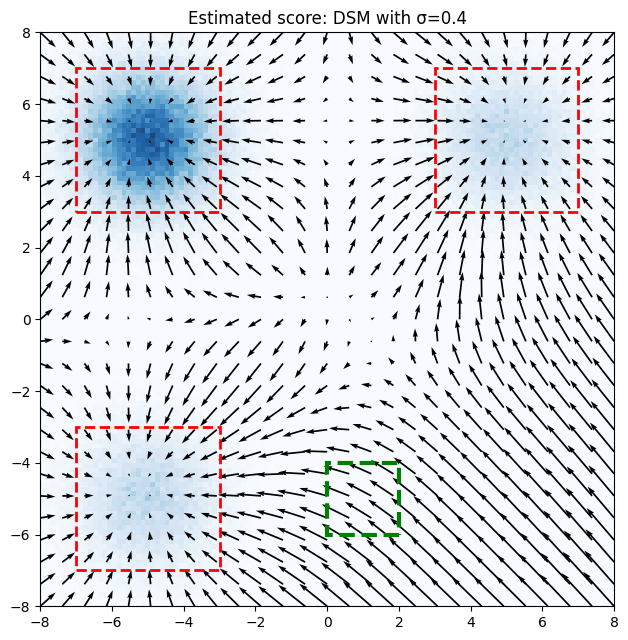

In [14]:
fig_dsm = make_panel(
    score_fn=lambda x: dsm05_model(x),
    title=f"Estimated score: DSM with σ={dsm_sigma}",
    lim=8.0, n_grid=27, arrow_scale=0.35,
    samples_for_density=samples,
    rects=rectangles,
    low_rect = Rm
)
plt.show()

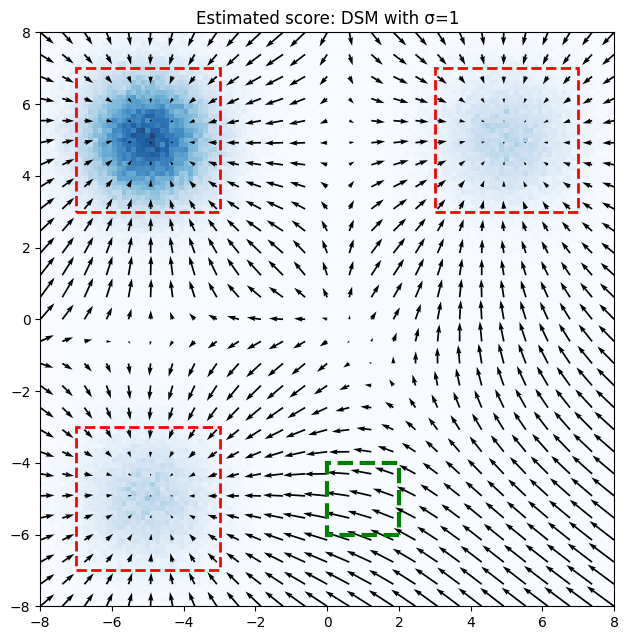

In [15]:
fig_dsm = make_panel(
    score_fn=lambda x: dsm1_model(x),
    title=f"Estimated score: DSM with σ={dsm_sigma2}",
    lim=8.0, n_grid=27, arrow_scale=0.35,
    samples_for_density=samples,
    rects=rectangles,
    low_rect = Rm
)
plt.show()

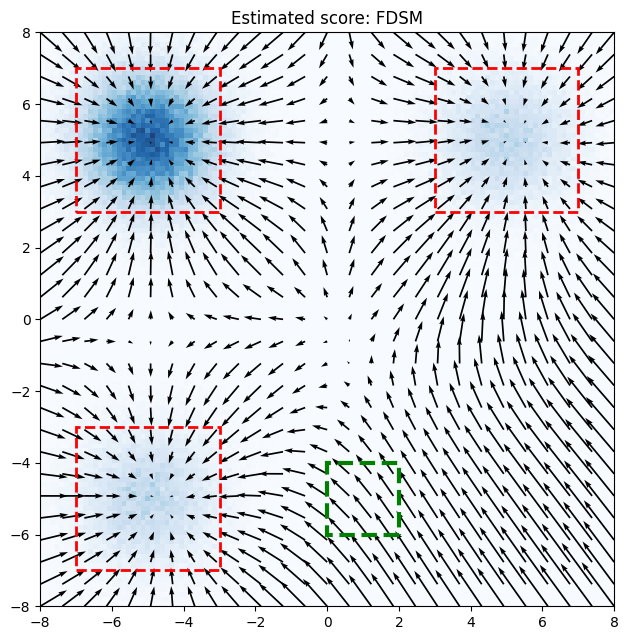

In [16]:
fig_fdsm = make_panel(
    score_fn=lambda x: fdsm_model(x),
    title="Estimated score: FDSM",
    lim=8.0, n_grid=27, arrow_scale=0.35,
    samples_for_density=samples,
    rects=rectangles,
    low_rect = Rm
)
plt.show()